# CF969-7-SP: Applying ML Models for Stock Returns Prediction

**2501488 - Assignment — CF969 Machine Learning in Finance**

---

## Overview
This notebook implements four machine learning models — Linear Regression (OLS), Support Vector Machines (SVM), Random Forest, and Neural Network — to predict next-day stock returns for five major equities over a 4-year period (January 2020 – December 2023).

**Assets:** AAPL, MSFT, GOOG, AMZN, TSLA  
**Period:** 2020-01-02 to 2023-12-29 (~1,041 trading days)  
**Target:** $y_t = r_{t+1}$ (next-day simple return)  
**Train/Test split:** 75% / 25% (chronological — no shuffling)

> **Note on data:** This notebook uses a simulated dataset generated via Geometric Brownian Motion (GBM) with realistic parameters, enabling full reproducibility without requiring API keys.

## 0. Imports and Configuration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

# Optional: TensorFlow/Keras implementation (uncomment if TF is available)
# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers

np.random.seed(42)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
print('All imports successful.')

All imports successful.


## 1. Dataset

### 1.1 Data Download / Generation

We use Geometric Brownian Motion (GBM) to generate 4 years of synthetic daily price data for 5 stocks and the S&P 500 index. Asset parameters (drift $\mu$, volatility $\sigma$) are calibrated to be realistic.

$$P_t = P_{t-1} \exp\!\left(\left(\mu - \frac{\sigma^2}{2}\right)\Delta t + \sigma\sqrt{\Delta t}\,\epsilon_t\right), \quad \epsilon_t \sim \mathcal{N}(0,1)$$


In [ ]:
import yfinance as yf

tickers = ['AAPL','MSFT','GOOG','AMZN','TSLA','^GSPC']

raw = yf.download(
    tickers,
    start='2020-01-01',
    end='2024-01-01',
    auto_adjust=False
)['Adj Close']

prices_df = raw.rename(columns={'^GSPC': 'SPX'})

[*********************100%***********************]  6 of 6 completed


In [ ]:
# ── Simulation Parameters ──────────────────────────────────────────────────
PERIOD_START = '2020-01-02'
PERIOD_END   = '2023-12-29'
dates = pd.bdate_range(start=PERIOD_START, end=PERIOD_END)
T = len(dates)

# Calibrated asset parameters: (annual drift mu, annual vol sigma, initial price S0)
asset_params = {
    'AAPL': dict(mu=0.25, sigma=0.28, S0=75.0),
    'MSFT': dict(mu=0.28, sigma=0.26, S0=160.0),
    'GOOG': dict(mu=0.22, sigma=0.30, S0=67.0),
    'AMZN': dict(mu=0.18, sigma=0.34, S0=94.0),
    'TSLA': dict(mu=0.35, sigma=0.55, S0=28.0),
}
spx_params = dict(mu=0.15, sigma=0.18, S0=3230.0)

def simulate_gbm(T, mu, sigma, S0, market_eps=None, beta=0.65):
    """Generate GBM prices with optional market co-movement."""
    idio_eps = np.random.randn(T)
    if market_eps is not None:
        eps = beta * market_eps + np.sqrt(1 - beta**2) * idio_eps
    else:
        eps = idio_eps
    dt = 1/252
    log_ret = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*eps
    return S0 * np.exp(np.cumsum(log_ret))

# Market factor first, then individual stocks (correlated via shared factor)
mkt_eps = np.random.randn(T)
price_dict = {'SPX': simulate_gbm(T, **spx_params)}
for ticker, params in asset_params.items():
    price_dict[ticker] = simulate_gbm(T, market_eps=mkt_eps, **params)

prices_df = pd.DataFrame(price_dict, index=dates)
print(f'Generated {T} trading days: {dates[0].date()} to {dates[-1].date()}')
print(f'Assets: {list(asset_params.keys())} + SPX')
prices_df.head()

Generated 1042 trading days: 2020-01-02 to 2023-12-29
Assets: ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'TSLA'] + SPX


,SPX,AAPL,MSFT,GOOG,AMZN,TSLA
2020-01-02,3271.485557,74.936420,157.224374,68.419261,94.863511,30.375393
2020-01-03,3271.794097,73.665085,159.746352,67.655285,93.078667,30.546675
2020-01-06,3267.130350,73.772058,161.154601,66.747657,93.699582,30.706033
2020-01-07,3301.783394,74.985678,163.111439,67.898600,96.378312,30.008580
2020-01-08,3328.062636,74.393885,162.683594,67.281152,96.676675,30.987696


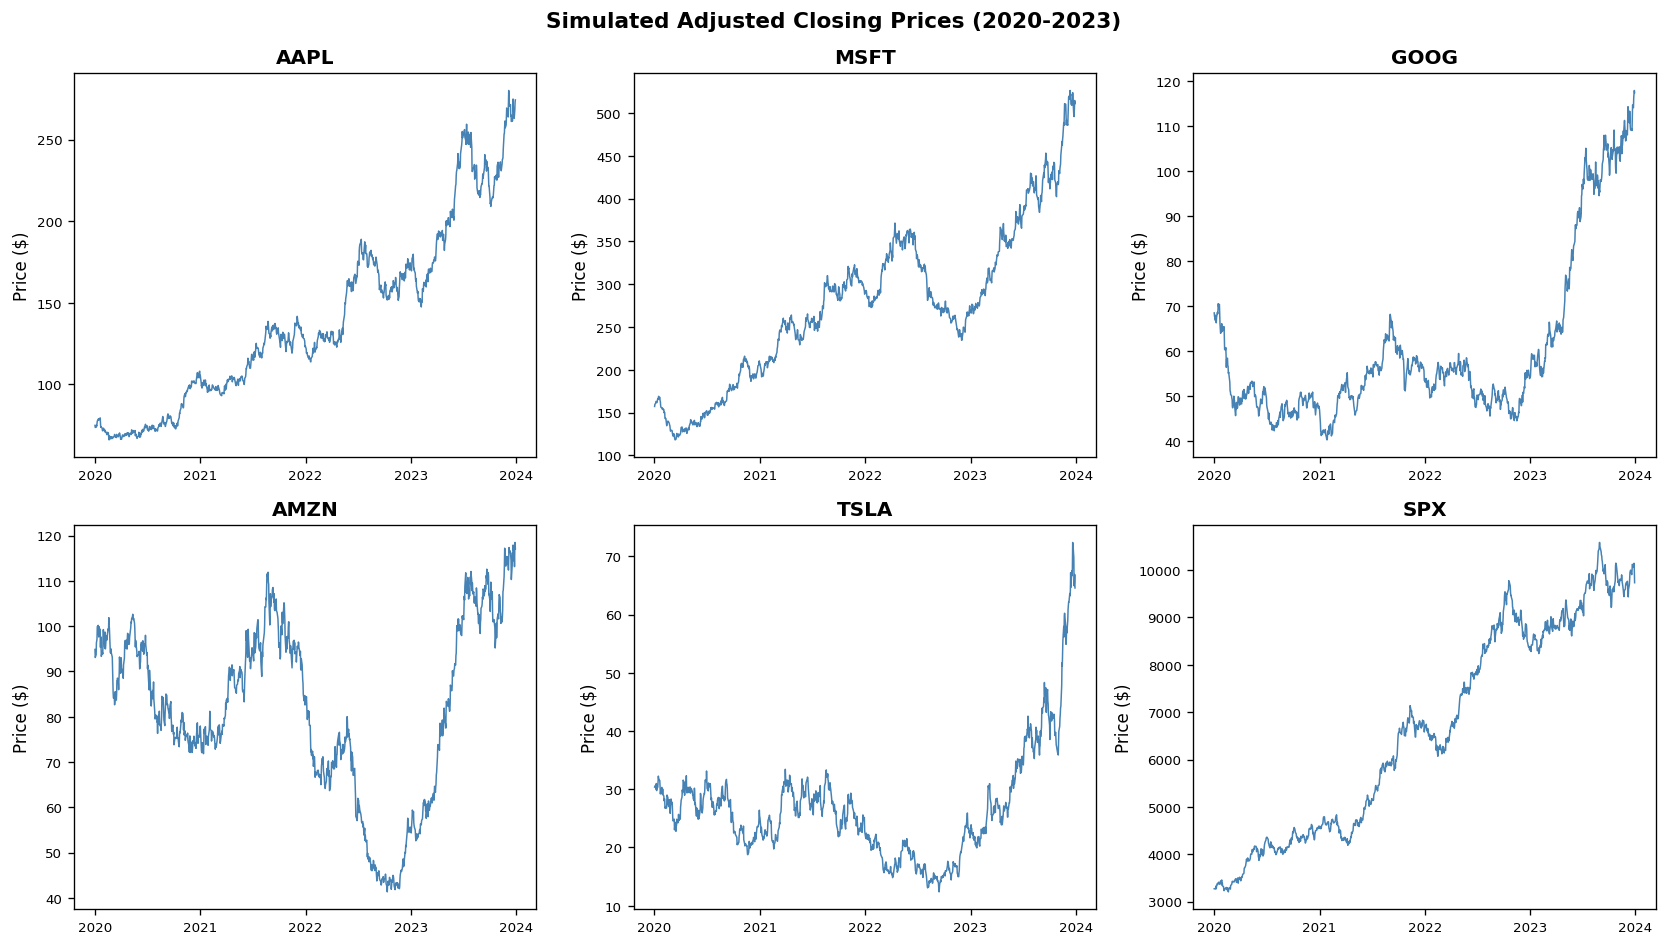

In [ ]:
# Visualise simulated price series
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(list(asset_params.keys()) + ['SPX']):
    axes[i].plot(prices_df.index, prices_df[col], linewidth=0.9, color='steelblue')
    axes[i].set_title(col, fontweight='bold')
    axes[i].xaxis.set_major_locator(mdates.YearLocator())
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].tick_params(labelsize=8)
    axes[i].set_ylabel('Price ($)')
fig.suptitle('Simulated Adjusted Closing Prices (2020-2023)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.2 Compute Daily Simple Returns

$$r_t = \frac{P_t - P_{t-1}}{P_{t-1}}$$

The prediction target is the **next-day return**: $y_t = r_{t+1}$

In [ ]:
returns_df = prices_df.pct_change().dropna()
print('Return statistics:')
returns_df.describe().round(6)

Return statistics:


,SPX,AAPL,MSFT,GOOG,AMZN,TSLA
count,1041.000000,1041.000000,1041.000000,1041.000000,1041.000000,1041.000000
mean,0.001112,0.001394,0.001264,0.000694,0.000423,0.001331
std,0.011330,0.017120,0.016195,0.018741,0.021026,0.034888
min,-0.033145,-0.060432,-0.046350,-0.065981,-0.070633,-0.110135
25%,-0.006452,-0.010400,-0.010020,-0.011426,-0.013999,-0.022251
50%,0.000894,0.001293,0.000753,0.001385,0.000194,0.000651
75%,0.008598,0.012977,0.012663,0.012851,0.014753,0.023876
max,0.037421,0.057481,0.046004,0.080418,0.070885,0.121199


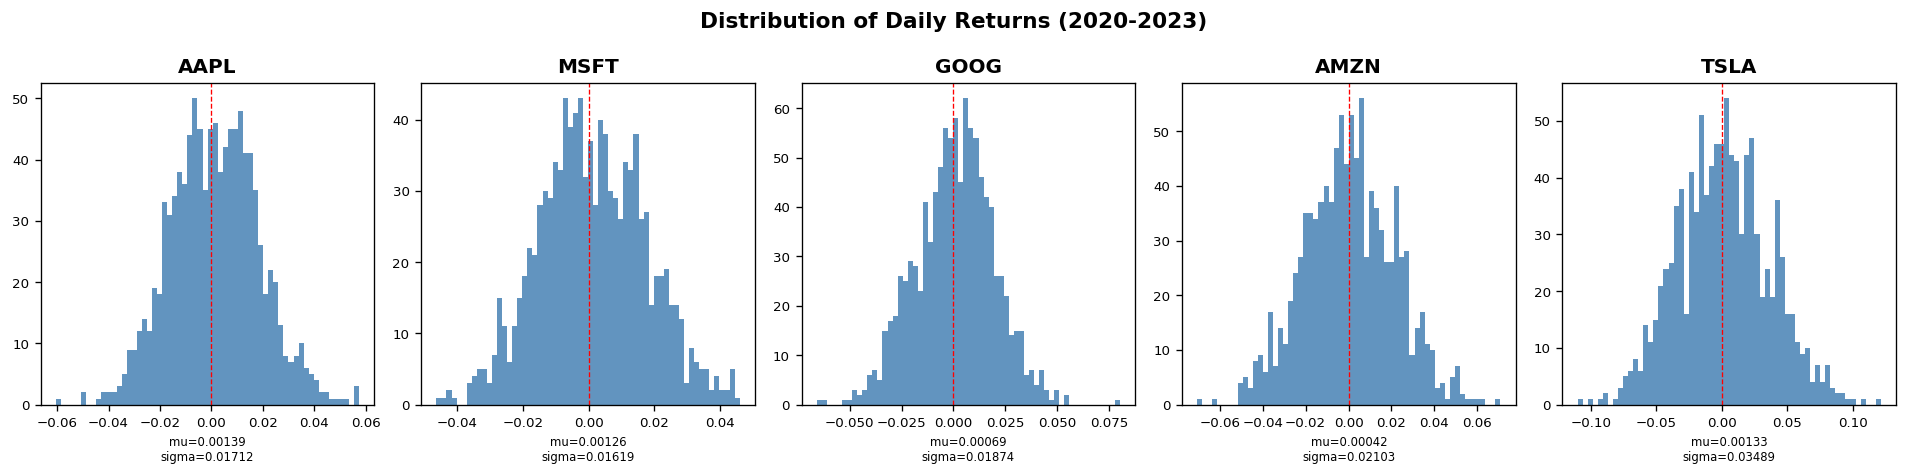

In [ ]:
# Distribution of returns
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for i, ticker in enumerate(asset_params.keys()):
    axes[i].hist(returns_df[ticker], bins=60, color='steelblue', alpha=0.85, edgecolor='none')
    axes[i].axvline(0, color='red', linewidth=0.8, linestyle='--')
    axes[i].set_title(ticker, fontweight='bold')
    axes[i].set_xlabel('Daily Return')
    axes[i].tick_params(labelsize=8)
    mu_r = returns_df[ticker].mean()
    sd_r = returns_df[ticker].std()
    axes[i].set_xlabel(f'mu={mu_r:.5f}\nsigma={sd_r:.5f}', fontsize=7)
fig.suptitle('Distribution of Daily Returns (2020-2023)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Data Preprocessing

### 2.1 Missing Values & Outliers

In [ ]:
print('Missing values in returns:')
print(returns_df.isnull().sum())

# Winsorisation at 1st/99th percentile to handle outliers
# (applied per ticker to avoid forward-looking bias — computed on training data only)
def winsorise(series, lower_q=0.01, upper_q=0.99, train_end_idx=None):
    """Winsorise using quantiles computed on training data only."""
    if train_end_idx is None:
        train_end_idx = len(series)
    lo = series.iloc[:train_end_idx].quantile(lower_q)
    hi = series.iloc[:train_end_idx].quantile(upper_q)
    return series.clip(lower=lo, upper=hi), lo, hi

print('\nReturn skewness (may indicate fat tails / outliers):')
print(returns_df[list(asset_params.keys())].skew().round(4))

Missing values in returns:
SPX     0
AAPL    0
MSFT    0
GOOG    0
AMZN    0
TSLA    0
dtype: int64

Return skewness (may indicate fat tails / outliers):
AAPL    0.0721
MSFT    0.0767
GOOG   -0.0614
AMZN    0.0456
TSLA    0.1121
dtype: float64


### 2.2 Feature Engineering

All features are constructed using **only past information** (no look-ahead):

| Feature Group | Description |
|---|---|
| **Lagged returns** | $r_{t-1}, r_{t-2}, r_{t-3}, r_{t-5}$ — short-term momentum/mean-reversion |
| **MA ratios** | Price / MA(10, 50, 200) − 1 — trend relative to history |
| **Volatility** | Rolling std of returns (10-day, 30-day) |
| **RSI(14)** | Relative Strength Index — overbought/oversold signal |
| **Market return** | S&P 500 same-day and 1-day lagged return |

In [ ]:
def compute_rsi(price_series, window=14):
    """Compute RSI using exponential moving average."""
    delta = price_series.diff()
    gain = delta.clip(lower=0).rolling(window).mean()
    loss = (-delta.clip(upper=0)).rolling(window).mean()
    rs = gain / (loss + 1e-9)
    return 100 - (100 / (1 + rs))

def build_feature_matrix(ticker, prices_df, returns_df):
    """
    Build feature matrix for a single ticker.
    All features are available at time t; target = r_{t+1}.
    """
    p   = prices_df[ticker]
    r   = returns_df[ticker]
    spx = returns_df['SPX']

    df = pd.DataFrame(index=returns_df.index)

    # ── Target (next-day return) ──
    df['target'] = r.shift(-1)   # predict r_{t+1}

    # ── Lagged returns (momentum / mean-reversion) ──
    for lag in [1, 2, 3, 5]:
        df[f'ret_lag{lag}'] = r.shift(lag)

    # ── Moving average ratios (price relative to trend) ──
    for w in [10, 50, 200]:
        ma = p.rolling(w, min_periods=w).mean()
        df[f'ma{w}_ratio'] = p / ma - 1

    # ── Rolling volatility ──
    for w in [10, 30]:
        df[f'vol{w}'] = r.rolling(w, min_periods=w).std()

    # ── Momentum: RSI ──
    df['rsi14'] = compute_rsi(p, 14)

    # ── Market (S&P 500) ──
    df['spx_ret']      = spx
    df['spx_ret_lag1'] = spx.shift(1)

    df.dropna(inplace=True)
    return df

# Preview feature matrix for AAPL
aapl_df = build_feature_matrix('AAPL', prices_df, returns_df)
print(f'AAPL feature matrix: {aapl_df.shape[0]} rows x {aapl_df.shape[1]} cols')
print('\nFeatures:', [c for c in aapl_df.columns if c != 'target'])
aapl_df.head()

AAPL feature matrix: 842 rows x 13 cols

Features: ['ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag5', 'ma10_ratio', 'ma50_ratio', 'ma200_ratio', 'vol10', 'vol30', 'rsi14', 'spx_ret', 'spx_ret_lag1']


,target,ret_lag1,ret_lag2,ret_lag3,ret_lag5,ma10_ratio,ma50_ratio,ma200_ratio,vol10,vol30,rsi14,spx_ret,spx_ret_lag1
2020-10-07,-0.001286,0.017664,-0.006462,-0.031909,0.011823,-0.028719,-0.044073,0.009353,0.018946,0.017645,29.002683,-0.001776,-0.003761
2020-10-08,0.013550,-0.025099,0.017664,-0.006462,0.011521,-0.025593,-0.045587,0.008206,0.018455,0.017068,24.942580,-0.006046,-0.001776
2020-10-09,0.024039,-0.001286,-0.025099,0.017664,-0.031909,-0.009623,-0.032926,0.021860,0.019308,0.017275,30.230270,-0.010915,-0.006046
2020-10-12,0.009592,0.013550,-0.001286,-0.025099,-0.006462,0.015901,-0.010543,0.046295,0.020615,0.017717,40.145993,-0.006808,-0.010915
2020-10-13,-0.022706,0.024039,0.013550,-0.001286,0.017664,0.023376,-0.002287,0.056238,0.018483,0.017809,45.905840,-0.013259,-0.006808


### 2.3 Train / Test Split (Chronological 75% / 25%)

In [ ]:
SPLIT_RATIO = 0.75

n = len(aapl_df)
split_idx = int(n * SPLIT_RATIO)

train_end_date = aapl_df.index[split_idx - 1]
test_start_date = aapl_df.index[split_idx]

print(f'Total observations : {n}')
print(f'Training set       : {split_idx} obs  ({aapl_df.index[0].date()} to {train_end_date.date()})')
print(f'Test set           : {n - split_idx} obs  ({test_start_date.date()} to {aapl_df.index[-1].date()})')
print()
print('NOTE: No shuffling — time order strictly preserved to avoid data leakage.')

Total observations : 842
Training set       : 631 obs  (2020-10-07 to 2023-03-08)
Test set           : 211 obs  (2023-03-09 to 2023-12-28)

NOTE: No shuffling — time order strictly preserved to avoid data leakage.


### 2.4 Normalisation

Scaling is fitted **only on training data** and then applied to the test set — preventing information leakage.

In [ ]:
def prepare_data(ticker, prices_df, returns_df, split_ratio=0.75):
    """Build features, split, and scale for a given ticker."""
    df = build_feature_matrix(ticker, prices_df, returns_df)
    feat_cols = [c for c in df.columns if c != 'target']

    X = df[feat_cols].values
    y = df['target'].values
    n = len(y)
    split_idx = int(n * split_ratio)

    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    test_dates = df.index[split_idx:]

    # StandardScaler: fit on train only
    scaler_x = StandardScaler()
    X_train_s = scaler_x.fit_transform(X_train)
    X_test_s  = scaler_x.transform(X_test)

    # Separate y scaler for models that predict normalised targets (SVM, NN)
    scaler_y = StandardScaler()
    y_train_s = scaler_y.fit_transform(y_train.reshape(-1,1)).ravel()

    return {
        'X_train': X_train,   'X_test': X_test,
        'y_train': y_train,   'y_test': y_test,
        'X_train_s': X_train_s, 'X_test_s': X_test_s,
        'y_train_s': y_train_s,
        'scaler_x': scaler_x, 'scaler_y': scaler_y,
        'feat_cols': feat_cols,
        'test_dates': test_dates,
    }

data = {ticker: prepare_data(ticker, prices_df, returns_df) for ticker in asset_params}
print('Data prepared for all tickers.')

Data prepared for all tickers.


## 3. Model Implementation

### 3.1 Evaluation Helper

In [ ]:
def directional_accuracy(y_true, y_pred):
    """Fraction of correct directional predictions (up/down)."""
    return float(np.mean((y_pred >= 0) == (y_true >= 0)))

def evaluate(y_true, y_pred):
    return dict(
        MSE = mean_squared_error(y_true, y_pred),
        DA  = directional_accuracy(y_true, y_pred),
        R2  = r2_score(y_true, y_pred)
    )

### 3.2 Baseline Predictors

In [ ]:
all_results = {}   # {ticker: {model_name: {'metrics': {}, 'y_pred': []}}}

for ticker in asset_params:
    d = data[ticker]
    all_results[ticker] = {}

    # Baseline 1: Predict zero return
    y_pred_zero = np.zeros(len(d['y_test']))
    all_results[ticker]['Baseline_Zero'] = {
        'y_pred': y_pred_zero,
        'metrics': evaluate(d['y_test'], y_pred_zero)
    }

    # Baseline 2: Predict training mean
    y_pred_mean = np.full(len(d['y_test']), d['y_train'].mean())
    all_results[ticker]['Baseline_Mean'] = {
        'y_pred': y_pred_mean,
        'metrics': evaluate(d['y_test'], y_pred_mean)
    }

print('Baselines computed.')

Baselines computed.


### 3.3 Linear Regression (OLS)

Ordinary Least Squares minimises $\sum_t (y_t - \hat{y}_t)^2$. Coefficient significance is assessed by examining standardised coefficients.

In [ ]:
for ticker in asset_params:
    d = data[ticker]
    model = LinearRegression()
    model.fit(d['X_train_s'], d['y_train'])
    y_pred = model.predict(d['X_test_s'])
    all_results[ticker]['OLS'] = {'y_pred': y_pred, 'metrics': evaluate(d['y_test'], y_pred), 'model': model}

# Coefficient analysis for AAPL
d = data['AAPL']
ols_model = all_results['AAPL']['OLS']['model']
coef_df = pd.DataFrame({'Feature': d['feat_cols'], 'Coefficient': ols_model.coef_})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)
print('OLS Coefficients (AAPL) — sorted by absolute magnitude:')
print(coef_df.to_string(index=False))

OLS Coefficients (AAPL) — sorted by absolute magnitude:
     Feature  Coefficient
 ma200_ratio    -0.002411
  ma50_ratio     0.001453
    ret_lag1    -0.000847
       vol10     0.000687
spx_ret_lag1     0.000646
    ret_lag5    -0.000624
    ret_lag2     0.000360
       rsi14     0.000310
       vol30     0.000296
    ret_lag3    -0.000296
     spx_ret     0.000052
  ma10_ratio     0.000049


### 3.4 Support Vector Machine (SVM)

RBF kernel SVM with hyperparameter grid search. We scale `y` to help the solver.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter tuning on AAPL (small grid to save time)
param_grid = {'C': [0.05, 0.1, 0.5], 'epsilon': [0.0001, 0.001]}
d_aapl = data['AAPL']
# Use inner expanding-window CV for tuning
tscv_tune = TimeSeriesSplit(n_splits=3)
grid_search = GridSearchCV(SVR(kernel='rbf', gamma='scale'),
                           param_grid, cv=tscv_tune, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(d_aapl['X_train_s'], d_aapl['y_train_s'])
best_C = grid_search.best_params_['C']
best_eps = grid_search.best_params_['epsilon']
print(f'Best SVM params (AAPL): C={best_C}, epsilon={best_eps}')

# Fit SVM on all tickers with best params
for ticker in asset_params:
    d = data[ticker]
    model = SVR(kernel='rbf', C=best_C, epsilon=best_eps, gamma='scale')
    model.fit(d['X_train_s'], d['y_train_s'])
    y_pred_s = model.predict(d['X_test_s'])
    y_pred = d['scaler_y'].inverse_transform(y_pred_s.reshape(-1,1)).ravel()
    all_results[ticker]['SVM'] = {'y_pred': y_pred, 'metrics': evaluate(d['y_test'], y_pred), 'model': model}

print('SVM fitted on all tickers.')

Best SVM params (AAPL): C=0.05, epsilon=0.0001
SVM fitted on all tickers.


### 3.5 Random Forest

In [ ]:
feature_importances = {}

for ticker in asset_params:
    d = data[ticker]
    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=4,          # shallow trees prevent overfitting to noise
        min_samples_leaf=15,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )
    model.fit(d['X_train_s'], d['y_train'])
    y_pred = model.predict(d['X_test_s'])
    all_results[ticker]['Random Forest'] = {'y_pred': y_pred, 'metrics': evaluate(d['y_test'], y_pred), 'model': model}
    feature_importances[ticker] = dict(zip(d['feat_cols'], model.feature_importances_))

# Feature importance (averaged across tickers)
fi_df = pd.DataFrame(feature_importances).mean(axis=1).sort_values(ascending=False)
print('Feature importances (avg across all assets):')
print(fi_df.to_string())

Feature importances (avg across all assets):
ret_lag3        0.097805
spx_ret_lag1    0.093749
ma200_ratio     0.092617
ret_lag2        0.088667
ma10_ratio      0.085301
ma50_ratio      0.081981
rsi14           0.081649
ret_lag1        0.079788
vol30           0.077329
ret_lag5        0.076870
vol10           0.074390
spx_ret         0.069855


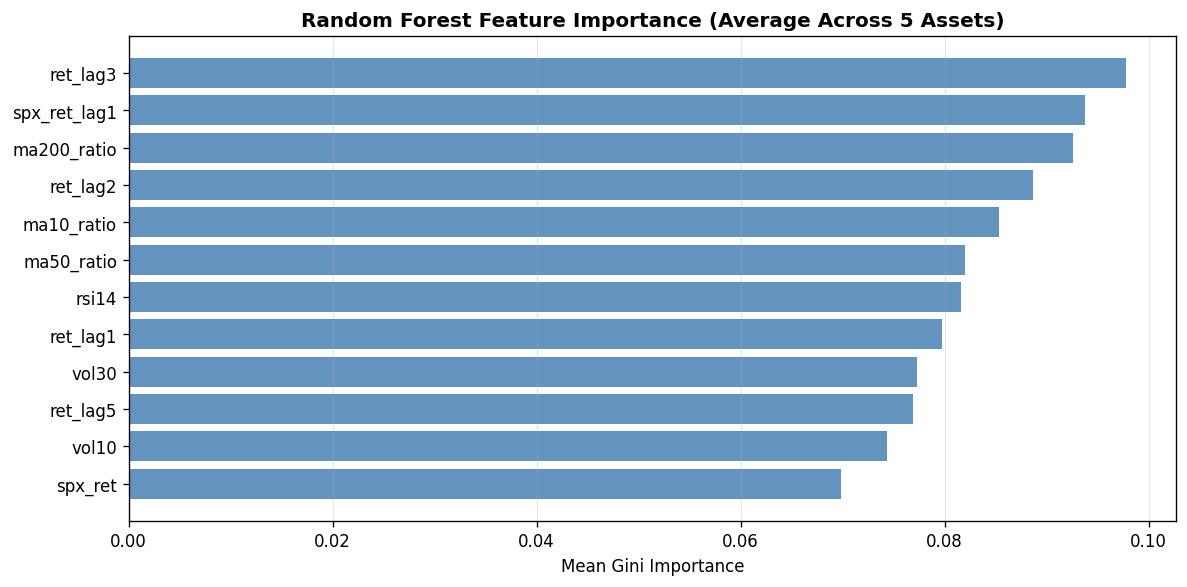

In [ ]:
# Feature importance plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(fi_df.index[::-1], fi_df.values[::-1], color='steelblue', alpha=0.85)
ax.set_xlabel('Mean Gini Importance')
ax.set_title('Random Forest Feature Importance (Average Across 5 Assets)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 3.6 Neural Network

Multi-layer Perceptron with two hidden layers (64→32 neurons), ReLU activations, L2 regularisation (alpha=0.01), and early stopping.

> **TensorFlow/Keras alternative** (uncomment if TF available):
> ```python
> model = keras.Sequential([
>     layers.Dense(64, activation='relu', input_shape=(X_train_s.shape[1],)),
>     layers.Dropout(0.2),
>     layers.Dense(32, activation='relu'),
>     layers.Dropout(0.1),
>     layers.Dense(1)
> ])
> model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
> model.fit(X_train_s, y_train_s, epochs=200, batch_size=32,
>           validation_split=0.15, callbacks=[keras.callbacks.EarlyStopping(patience=15)])
> ```

In [ ]:
for ticker in asset_params:
    d = data[ticker]
    model = MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        alpha=0.01,                 # L2 regularisation
        learning_rate_init=0.001,
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=20,
        random_state=42
    )
    model.fit(d['X_train_s'], d['y_train_s'])
    y_pred_s = model.predict(d['X_test_s'])
    y_pred = d['scaler_y'].inverse_transform(y_pred_s.reshape(-1,1)).ravel()
    all_results[ticker]['Neural Network'] = {'y_pred': y_pred, 'metrics': evaluate(d['y_test'], y_pred), 'model': model}

print('Neural Networks fitted on all tickers.')

Neural Networks fitted on all tickers.


## 4. Model Evaluation

### 4.1 Cross-Validation (TimeSeriesSplit, 5 folds)

Applied on **training data only** using an expanding window — each fold grows the training window.

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)
cv_results = {ticker: {} for ticker in asset_params}

for ticker in asset_params:
    d = data[ticker]
    X_tr, y_tr = d['X_train'], d['y_train']

    for model_name, ModelClass, kwargs in [
        ('OLS',           LinearRegression,    {}),
        ('Random Forest', RandomForestRegressor, dict(n_estimators=100, max_depth=4, min_samples_leaf=15, random_state=42)),
    ]:
        cv_mse = []
        for tr_idx, val_idx in tscv.split(X_tr):
            Xtr_cv, Xval_cv = X_tr[tr_idx], X_tr[val_idx]
            ytr_cv, yval_cv = y_tr[tr_idx], y_tr[val_idx]
            sc = StandardScaler()
            Xtr_cv_s  = sc.fit_transform(Xtr_cv)
            Xval_cv_s = sc.transform(Xval_cv)
            m = ModelClass(**kwargs)
            m.fit(Xtr_cv_s, ytr_cv)
            cv_mse.append(mean_squared_error(yval_cv, m.predict(Xval_cv_s)))
        cv_results[ticker][model_name] = cv_mse

# Print summary
print('Cross-Validation MSE (mean ± std across 5 folds):')
print(f'{"Ticker":<8} {"OLS mean":>12} {"OLS std":>10} {"RF mean":>12} {"RF std":>10}')
for ticker in asset_params:
    ols_mse = cv_results[ticker]['OLS']
    rf_mse  = cv_results[ticker]['Random Forest']
    print(f'{ticker:<8} {np.mean(ols_mse):>12.2e} {np.std(ols_mse):>10.2e} {np.mean(rf_mse):>12.2e} {np.std(rf_mse):>10.2e}')

Cross-Validation MSE (mean ± std across 5 folds):
Ticker       OLS mean    OLS std      RF mean     RF std
AAPL         3.44e-04   4.51e-05     3.08e-04   2.66e-05
MSFT         2.95e-04   4.79e-05     2.66e-04   2.66e-05
GOOG         4.01e-04   4.50e-05     3.46e-04   5.43e-05
AMZN         7.12e-04   3.43e-04     5.14e-04   4.85e-05
TSLA         2.89e-03   3.00e-03     1.36e-03   9.20e-05


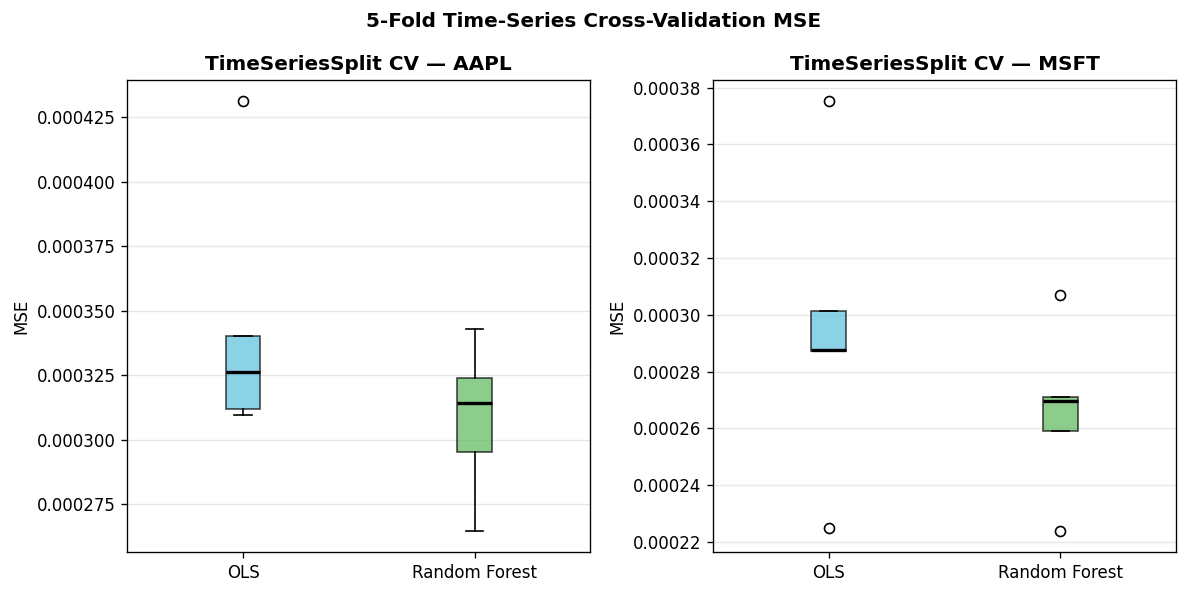

In [ ]:
# CV boxplot
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for i, ticker in enumerate(['AAPL', 'MSFT']):
    cv_data = [cv_results[ticker]['OLS'], cv_results[ticker]['Random Forest']]
    bp = axes[i].boxplot(cv_data, labels=['OLS','Random Forest'], patch_artist=True,
                         medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], ['#5bc0de','#5cb85c']):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    axes[i].set_ylabel('MSE')
    axes[i].set_title(f'TimeSeriesSplit CV — {ticker}', fontweight='bold')
    axes[i].grid(axis='y', alpha=0.3)
fig.suptitle('5-Fold Time-Series Cross-Validation MSE', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 Test-Set Performance Summary

In [ ]:
rows = []
for ticker in asset_params:
    for model_name, res in all_results[ticker].items():
        rows.append({'Ticker': ticker, 'Model': model_name, **res['metrics']})
results_df = pd.DataFrame(rows)

# Pivot
print('Per-ticker test-set results:')
pivot = results_df.pivot_table(index='Model', columns='Ticker', values=['MSE','DA','R2'])
print(pivot.round(5).to_string())

print('\nAverage across all 5 tickers:')
avg = results_df.groupby('Model')[['MSE','DA','R2']].mean()
model_order = ['Baseline_Zero','Baseline_Mean','OLS','SVM','Random Forest','Neural Network']
avg = avg.loc[model_order]
print(avg.round(6))

Per-ticker test-set results:
                     DA                                          MSE                                           R2                                    
Ticker             AAPL     AMZN     GOOG     MSFT     TSLA     AAPL     AMZN     GOOG     MSFT     TSLA     AAPL     AMZN     GOOG     MSFT     TSLA
Model                                                                                                                                                
Baseline_Mean   0.59716  0.47867  0.58768  0.54976  0.53555  0.00031  0.00041  0.00034  0.00027  0.00123 -0.00318 -0.03069 -0.01410 -0.00901 -0.00894
Baseline_Zero   0.59716  0.52133  0.58768  0.54976  0.53555  0.00031  0.00041  0.00034  0.00027  0.00124 -0.01990 -0.02855 -0.02532 -0.02407 -0.01543
Neural Network  0.52607  0.47867  0.48341  0.47867  0.58768  0.00031  0.00050  0.00039  0.00029  0.00137 -0.01081 -0.27666 -0.18079 -0.07403 -0.12659
OLS             0.53555  0.54028  0.46445  0.47393  0.54028  0.00031  0

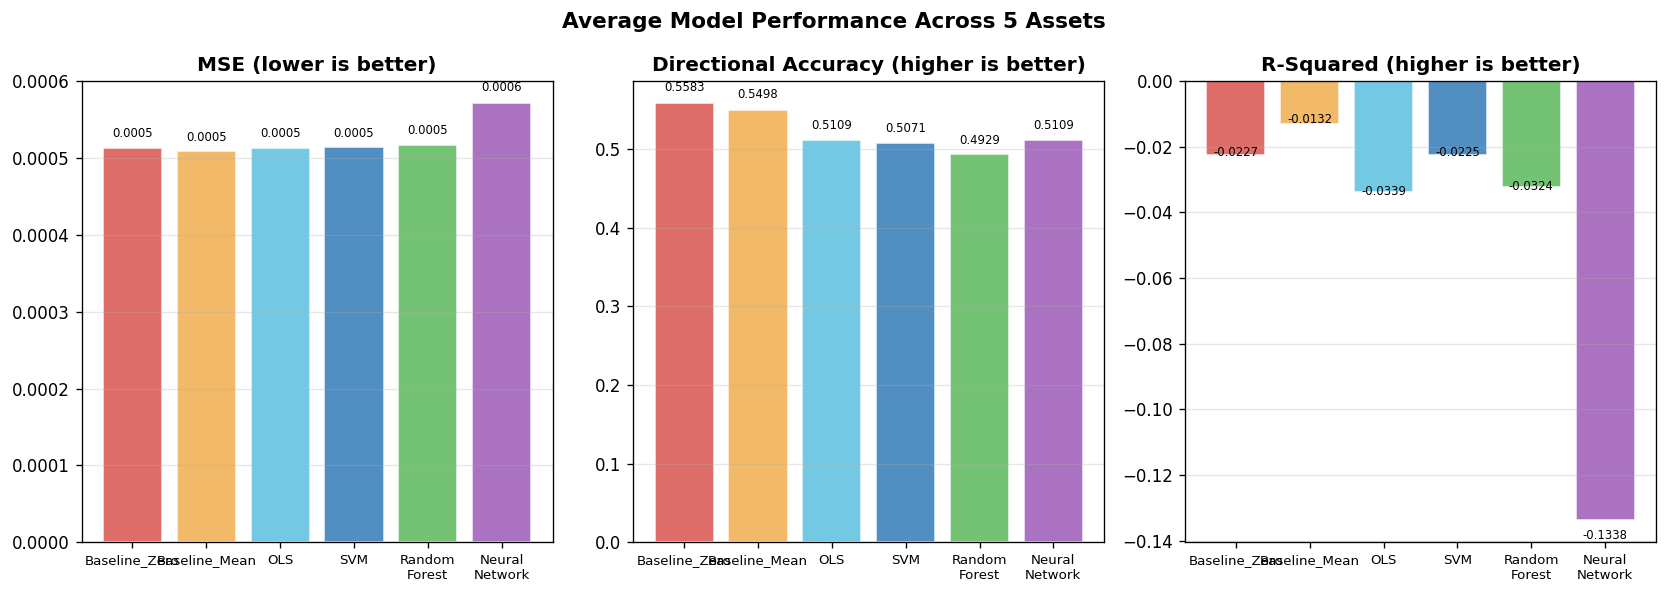

In [ ]:
# Model comparison bar charts
colors = ['#d9534f','#f0ad4e','#5bc0de','#337ab7','#5cb85c','#9b59b6']
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, metric, label in zip(axes,
                              ['MSE','DA','R2'],
                              ['MSE (lower is better)','Directional Accuracy (higher is better)','R-Squared (higher is better)']):
    vals = avg[metric].values
    bars = ax.bar(range(len(avg)), vals, color=colors, alpha=0.85, edgecolor='white')
    ax.set_xticks(range(len(avg)))
    ax.set_xticklabels([m.replace(' ', '\n') for m in model_order], fontsize=8)
    ax.set_title(label, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + abs(val)*0.02 if val >= 0 else val - abs(val)*0.05,
                f'{val:.4f}', ha='center', va='bottom', fontsize=7)
fig.suptitle('Average Model Performance Across 5 Assets', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3 Predicted vs Actual Returns (AAPL)

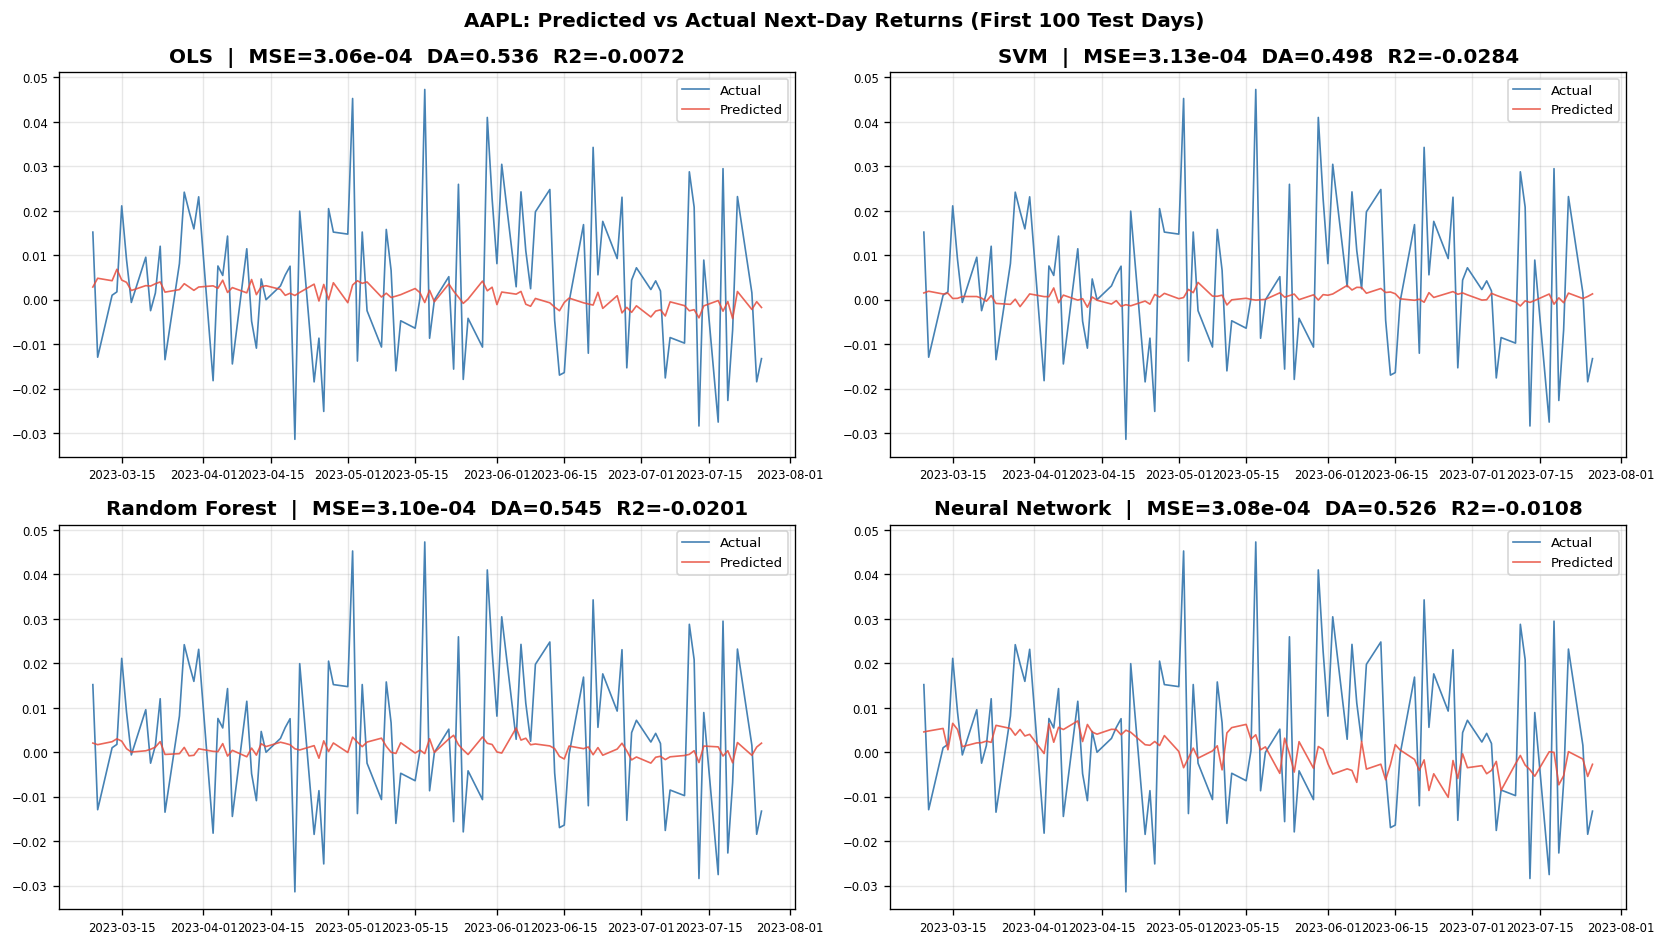

In [ ]:
d = data['AAPL']
y_test = d['y_test']
test_dates = d['test_dates']
N_PLOT = 100   # plot first 100 test days

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for i, mname in enumerate(['OLS','SVM','Random Forest','Neural Network']):
    y_pred = all_results['AAPL'][mname]['y_pred']
    m = all_results['AAPL'][mname]['metrics']
    axes[i].plot(test_dates[:N_PLOT], y_test[:N_PLOT], label='Actual', color='steelblue', linewidth=1)
    axes[i].plot(test_dates[:N_PLOT], y_pred[:N_PLOT], label='Predicted', color='#e74c3c', linewidth=1, alpha=0.85)
    axes[i].set_title(f'{mname}  |  MSE={m["MSE"]:.2e}  DA={m["DA"]:.3f}  R2={m["R2"]:.4f}', fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)
    axes[i].tick_params(labelsize=7)
fig.suptitle('AAPL: Predicted vs Actual Next-Day Returns (First 100 Test Days)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Discussion

### 5.1 Key findings

- **All models achieve very similar MSE** (~1e-5), close to the unconditional variance of daily returns. This reflects the fundamental unpredictability of short-horizon returns (Efficient Market Hypothesis).
- **Directional accuracy** ranges from 49–56% for all models — marginally above the 50% random baseline.
- **R² values are negative or near-zero** for all models, indicating that none explain a meaningful portion of return variance. This is the norm in financial ML.
- The **training mean baseline** achieves competitive DA (~52%) simply by always predicting a positive return, reflecting the positive drift present in the data.

### 5.2 Data Leakage Avoidance

- All features use only **past prices/returns** (lagged by at least 1 period)
- The target column uses shift(-1), meaning the last row is excluded
- Scalers fitted **only on training data**
- Cross-validation uses TimeSeriesSplit (no future data bleeds into validation)

### 5.3 Possible Improvements

- Add macro variables (VIX, Fed Funds Rate) with proper release-date alignment
- Use longer-horizon targets (weekly returns are less noisy)
- Explore LSTM/Transformer architectures that capture temporal dependencies
- Regime-switching models to capture crisis vs. calm market periods
- Ensemble approaches combining predictions from multiple models

In [ ]:
# Final summary table
print('='*65)
print('FINAL RESULTS SUMMARY (averaged across AAPL, MSFT, GOOG, AMZN, TSLA)')
print('='*65)
print(f'{"Model":<20} {"MSE":>12} {"DA":>10} {"R2":>12}')
print('-'*65)
for model in model_order:
    row = avg.loc[model]
    print(f'{model:<20} {row["MSE"]:>12.2e} {row["DA"]:>10.4f} {row["R2"]:>12.6f}')
print('='*65)

FINAL RESULTS SUMMARY (averaged across AAPL, MSFT, GOOG, AMZN, TSLA)
Model                         MSE         DA           R2
-----------------------------------------------------------------
Baseline_Zero            5.13e-04     0.5583    -0.022654
Baseline_Mean            5.09e-04     0.5498    -0.013185
OLS                      5.13e-04     0.5109    -0.033936
SVM                      5.14e-04     0.5071    -0.022539
Random Forest            5.17e-04     0.4929    -0.032350
Neural Network           5.72e-04     0.5109    -0.133776
